# Performance Comparison

In [ ]:
team = "McLaren"
grand_prix = "Japanese Grand Prix"
year = 2025

In [2]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *
from src.feature_engineering import *

In [3]:
session = fastf1.get_session(year, grand_prix, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, team)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(year, grand_prix, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {year} {grand_prix} {driver_1} and {driver_2} not found: {e}")

req         WARNING 	DEFAULT CACHE ENABLED! (205.96 MB) C:\Users\joseg\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']



Processed data for 2025 Japanese Grand Prix ALO and STR found in cache.
Driver 1: ALO, Driver 2: STR, Segment: Q1


In [4]:
print(f"=== Teammate Analysis for {year} {grand_prix} ===")
print(f"Driver 1: {driver_1}, Lap Time: {lap_1['LapTime']}, Tyres: {lap_1['TyreCompound']}, Tyre Age: {lap_1['TyreAge']}")
print(f"Driver 2: {driver_2}, Lap Time: {lap_2['LapTime']}, Tyres: {lap_2['TyreCompound']}, Tyre Age: {lap_2['TyreAge']}")

print(f"Time delta between {driver_1} and {driver_2}: {-(lap_1['LapTime'] - lap_2['LapTime']):.2f} seconds")

=== Teammate Analysis for 2025 Japanese Grand Prix ===
Driver 1: ALO, Lap Time: 88.337, Tyres: SOFT, Tyre Age: 2
Driver 2: STR, Lap Time: 89.271, Tyres: SOFT, Tyre Age: 2
Time delta between ALO and STR: 0.93 seconds


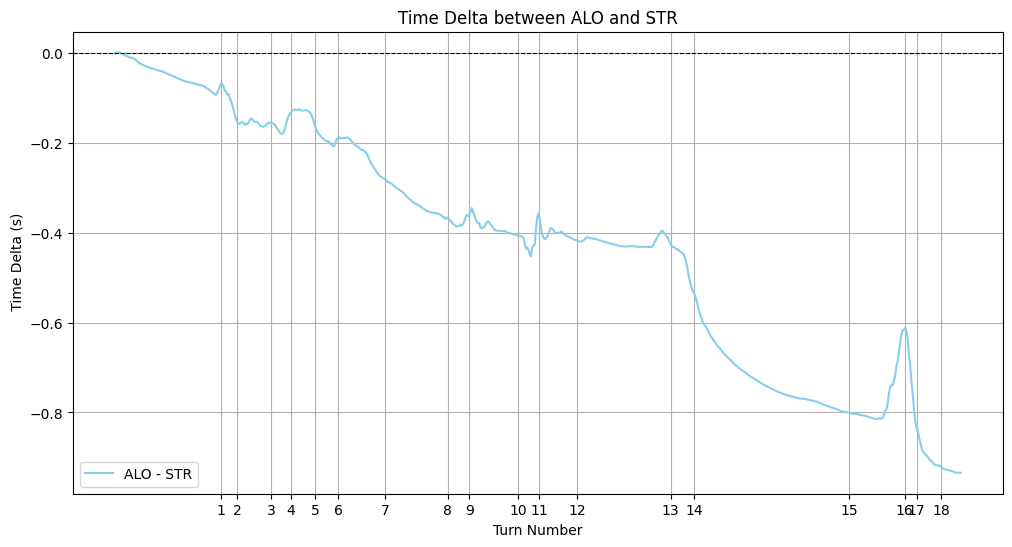

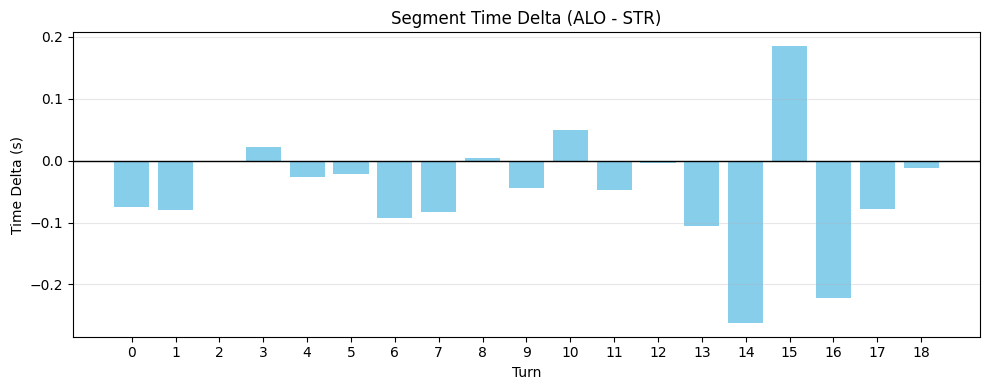

Segment time deltas between ALO and STR:
Start: -0.075 seconds
Turn 1: -0.080 seconds
Turn 2: -0.001 seconds
Turn 3: 0.022 seconds
Turn 4: -0.026 seconds
Turn 5: -0.022 seconds
Turn 6: -0.093 seconds
Turn 7: -0.083 seconds
Turn 8: 0.004 seconds
Turn 9: -0.044 seconds
Turn 10: 0.050 seconds
Turn 11: -0.047 seconds
Turn 12: -0.003 seconds
Turn 13: -0.106 seconds
Turn 14: -0.262 seconds
Turn 15: 0.185 seconds
Turn 16: -0.222 seconds
Turn 17: -0.078 seconds
Turn 18: -0.011 seconds


In [5]:
plot_variable_delta(lap_1["Telemetry"], lap_2["Telemetry"], driver_1, driver_2, "Time", turns, y_unit="s")
segment_times_1 = analyze_segment_times(lap_1["Telemetry"], turns)
segment_times_2 = analyze_segment_times(lap_2["Telemetry"], turns)
segment_time_deltas = barplot_segment_time_delta(segment_times_1, segment_times_2, driver_1, driver_2, turns)
print(f"Segment time deltas between {driver_1} and {driver_2}:")
for turn, delta in enumerate(segment_time_deltas):
    if turn != 0:
        print(f"Turn {turn}: {delta:.3f} seconds")
    else:
        print(f"Start: {delta:.3f} seconds")